# Fraud Detection: Exploratory Data Analysis II
## Transaction Amounts per Class and Type


In [466]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [467]:
data = pd.read_csv('/content/CreditCardFraud_Dataset.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   TransactionID    10000 non-null  object
 1   Time             10000 non-null  int64 
 2   Amount           10000 non-null  int64 
 3   MerchantID       10000 non-null  object
 4   TransactionType  10000 non-null  object
 5   Class            10000 non-null  object
dtypes: int64(2), object(4)
memory usage: 468.9+ KB


# Transaction Amounts

The 10,000 transactions in the dataset have amounts that range from 1.00 to ~5,000.00 dollars. Notably, around 98% of the transaction amounts fall under 1,000 dollars.

The distribution of transaction amounts is strongly right-skewed, with a median of approximately 505 and a mean of 550, indicating a slight upward pull from higher-value transactions.

The interquartile range (IQR) spans from roughly 256 to 761, meaning that 50% of all transactions fall within this moderate range. Additionally, approximately 75% of transactions are below 761, confirming that most activity is concentrated at relatively low values.

However, the distribution exhibits a long upper tail, with transaction amounts reaching up to 4995. Values above approximately 1500 fall outside the typical range and appear as numerous outliers in the boxplot, indicating a significant presence of high-value transactions that deviate from the norm.

This combination of a dense central mass and a wide spread of extreme values suggests the existence of distinct transaction regimes, where high-value transactions may behave differently from the majority. As a result, transaction amount emerges as a potentially important feature for distinguishing between normal and fraudulent behavior.

In [468]:
# summary statistics
print(data["Amount"].describe())

count    10000.000000
mean       550.231800
std        490.886686
min          1.000000
25%        256.000000
50%        505.000000
75%        761.000000
max       4995.000000
Name: Amount, dtype: float64


In [469]:
# percentage of transactions with amounts equal to or below $1,000.00
print((data["Amount"] <= 1000).mean() * 100)

98.04


<Axes: title={'center': 'Transaction Amount Boxplot'}>

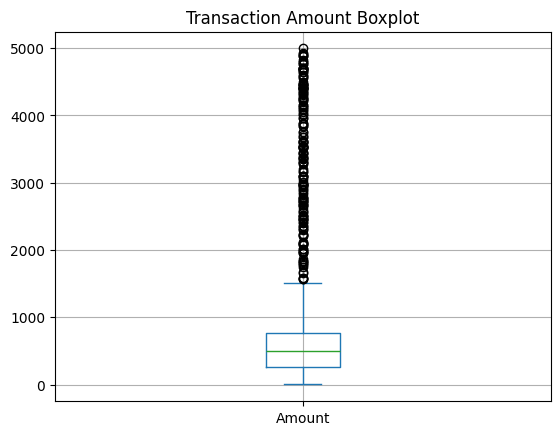

In [470]:
# boxplot of amount
data["Amount"].plot(
    kind="box",
    grid=True,
    title="Transaction Amount Boxplot"
    )

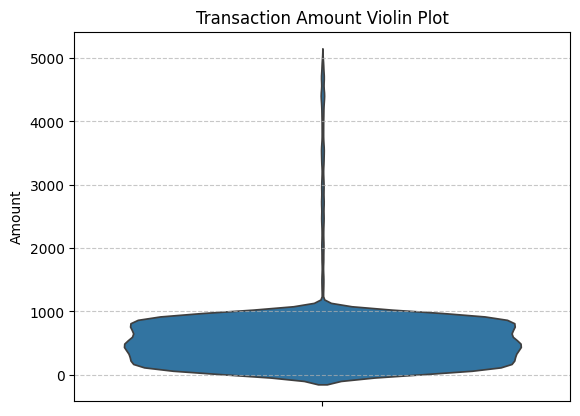

In [471]:
# violin plot of amount
sns.violinplot(
    data=data["Amount"],
    inner=None,
)
plt.title("Transaction Amount Violin Plot")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

<Axes: ylabel='Amount'>

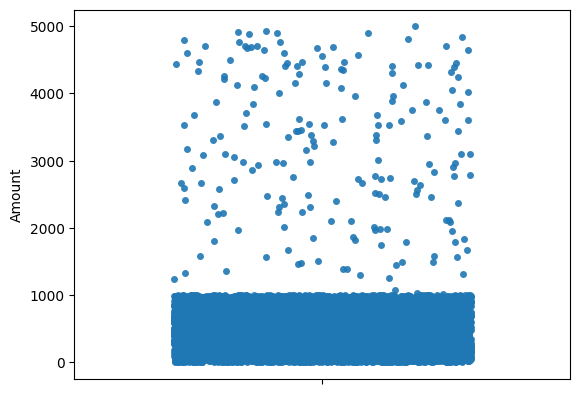

In [472]:
# strip plot of amount
sns.stripplot(
    y="Amount",
    data=data,
    jitter=0.3,
    alpha=0.9
    )

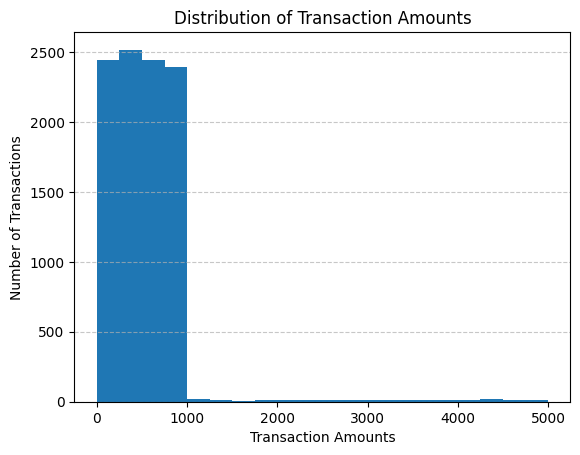

In [473]:
# histogram of amount
data["Amount"].plot(
    kind="hist",
    bins=20,
    )

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amounts")
plt.ylabel("Number of Transactions")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

<Axes: title={'center': 'Transaction Amounts (Sorted)'}, xlabel='Transaction ID', ylabel='Transaction Amount'>

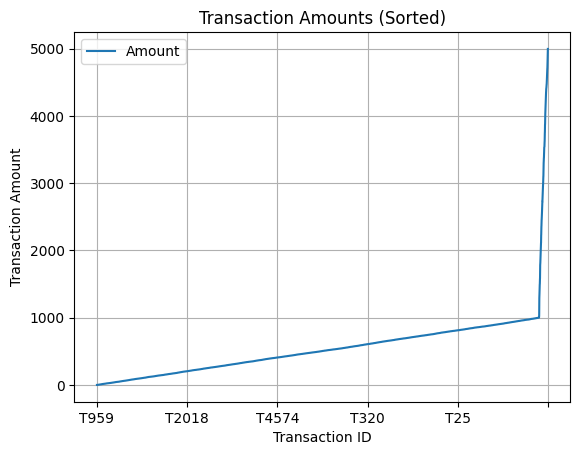

In [474]:
# line graph of amount
data.sort_values("Amount").plot(
    kind="line",
    x='TransactionID',
    y='Amount',
    title="Transaction Amounts (Sorted)",
    xlabel="Transaction ID",
    ylabel="Transaction Amount",
    grid=True
    )

# Transaction Amounts by Transaction Class

Although transaction amounts for fraudulent and normal transactions overlap significantly, fraudulent transactions tend to concentrate within common transaction ranges rather than extreme values. This suggests that transaction amount alone is not a strong discriminator for fraud detection and should be combined with other features.

In [475]:
# summary statistics by transaction class
print(round(data.groupby("Class")["Amount"].describe().T,2))

Class  Fraudulent   Normal
count      233.00  9767.00
mean       545.74   550.34
std        608.12   487.78
min          2.00     1.00
25%        235.00   257.00
50%        436.00   507.00
75%        741.00   761.00
max       4903.00  4995.00


In [476]:
# percentage of transactions with amounts equal to or below $1,000.00
print(round((data["Amount"] <= 1000).groupby(data["Class"]).mean() *100,2))

Class
Fraudulent    97.85
Normal        98.04
Name: Amount, dtype: float64


<Axes: title={'center': 'Amount'}, xlabel='Class'>

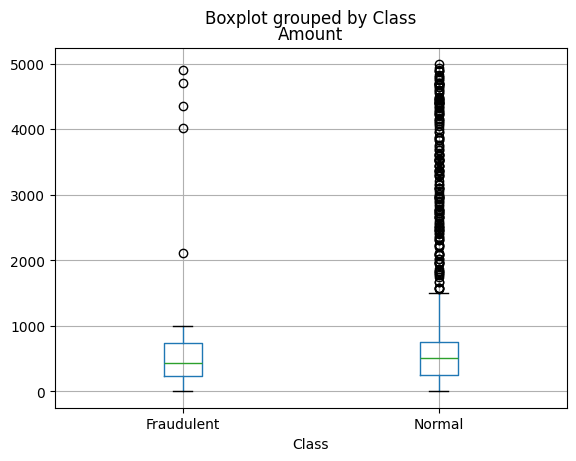

In [477]:
# boxplot of amount by transaction class
data.boxplot(
    column="Amount",
    by="Class"
    )

<Axes: xlabel='Class', ylabel='Amount'>

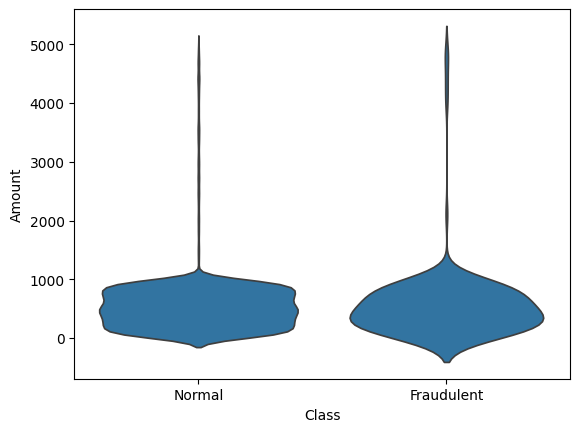

In [478]:
# violin plot
sns.violinplot(
    data=data,
    x="Class",
    y="Amount",
    inner=None
)

<Axes: xlabel='Class', ylabel='Amount'>

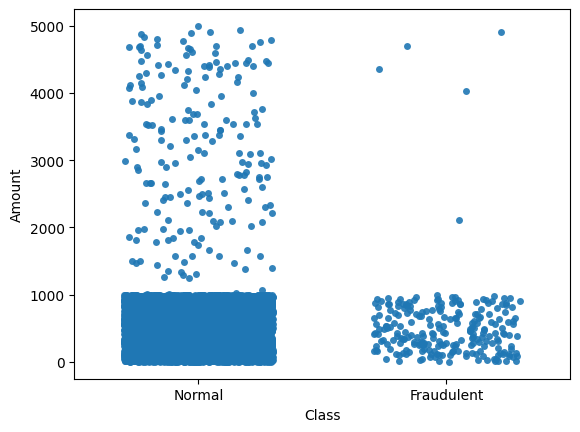

In [479]:
# strip plot
sns.stripplot(
    x="Class",
    y="Amount",
    data=data,
    jitter=0.3,
    alpha=0.9
    )

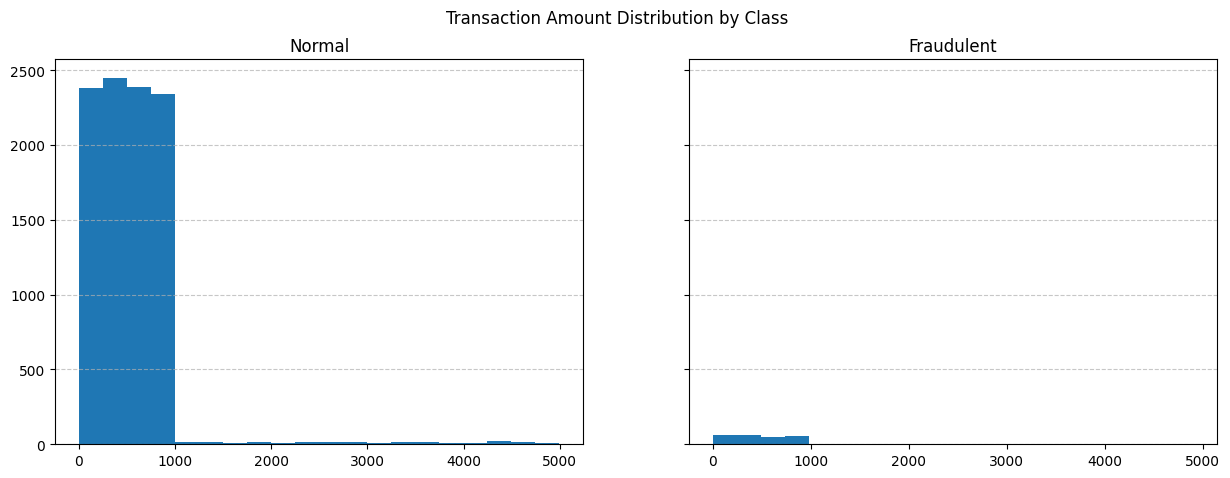

In [480]:
# histograms: transaction amounts by class
fig, ax = plt.subplots(1, 2, figsize=(15,5), sharey=True)
classes = data["Class"].unique()
for i, cls in enumerate(classes):
    subset = data[data["Class"] == cls]
    ax[i].hist(subset["Amount"], bins=20)
    ax[i].set_title(cls)
    ax[i].grid(axis="y", linestyle="--", alpha=0.7)

plt.suptitle("Transaction Amount Distribution by Class")
plt.show()

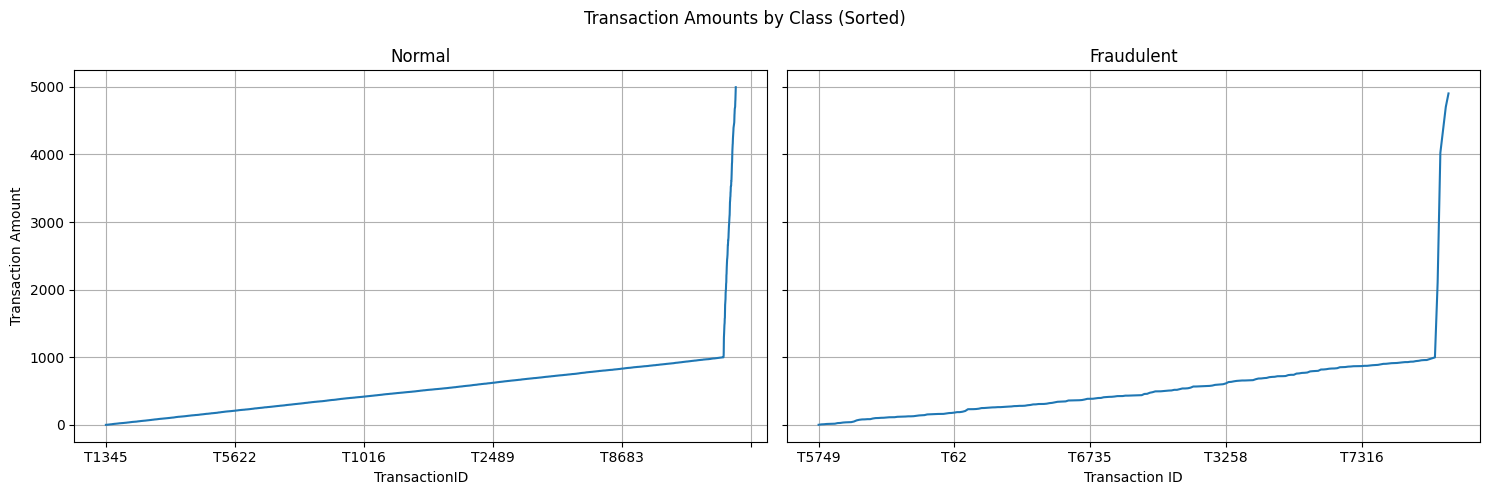

In [481]:
# line graphs
fig, ax = plt.subplots(1, 2, figsize=(15,5), sharey=True)
classes = data["Class"].unique()
for i, cls in enumerate(classes):
    subset = data[data["Class"] == cls].sort_values("Amount")

    subset.plot(
        kind="line",
        x="TransactionID",
        y="Amount",
        ax=ax[i],
        title=cls,
        grid=True,
        legend=False
    )

ax[i].set_xlabel("Transaction ID")
ax[0].set_ylabel("Transaction Amount")
plt.suptitle("Transaction Amounts by Class (Sorted)")
plt.tight_layout()
plt.show()

# Transaction Amount by Transaction Type

The distribution of transaction amounts is highly consistent across all transaction types (In-Store, Mobile, and Online), with nearly identical means and medians. The interquartile ranges are also similar, indicating that typical transaction behavior does not vary significantly by channel. This suggests that transaction amount alone does not differentiate transaction types in any meaningful way. However, all transaction types exhibit strong right-skewness, with a concentration of lower-value transactions and a long tail of high-value outliers reaching up to approximately \$5,000.

In [482]:
# summary statistics: transaction amounts by type
print(round(data.groupby("TransactionType")["Amount"].describe().T,2))

TransactionType  In-Store   Mobile   Online
count             3189.00  3393.00  3418.00
mean               553.19   554.33   543.40
std                510.20   477.58   485.58
min                  1.00     1.00     1.00
25%                251.00   269.00   245.25
50%                496.00   515.00   497.00
75%                765.00   769.00   749.75
max               4995.00  4801.00  4912.00


<Axes: title={'center': 'Amount'}, xlabel='TransactionType'>

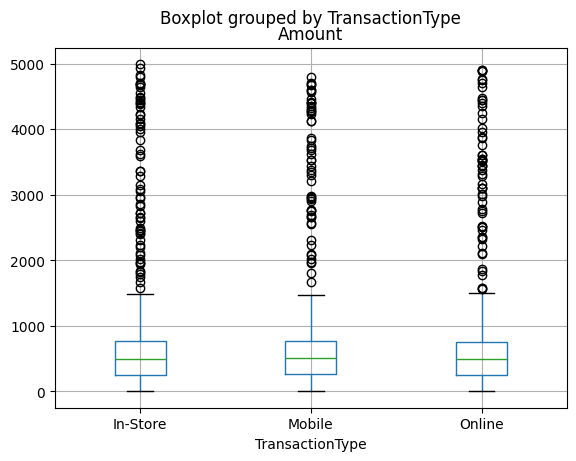

In [483]:
# boxplot of amount by transaction type
data.boxplot(
    column="Amount",
    by="TransactionType"
    )

<Axes: xlabel='TransactionType', ylabel='Amount'>

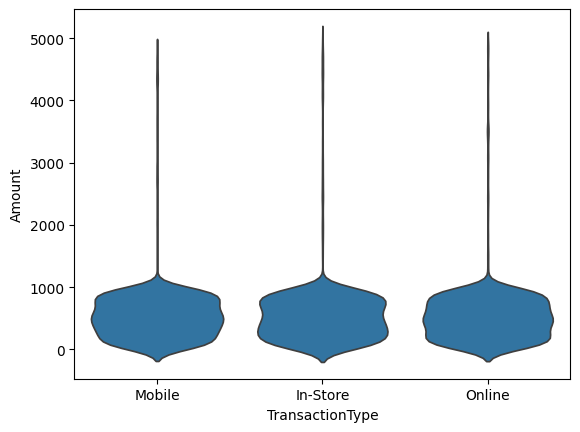

In [484]:
# violin plot
sns.violinplot(
    data=data,
    x="TransactionType",
    y="Amount",
    inner=None
)

<Axes: xlabel='TransactionType', ylabel='Amount'>

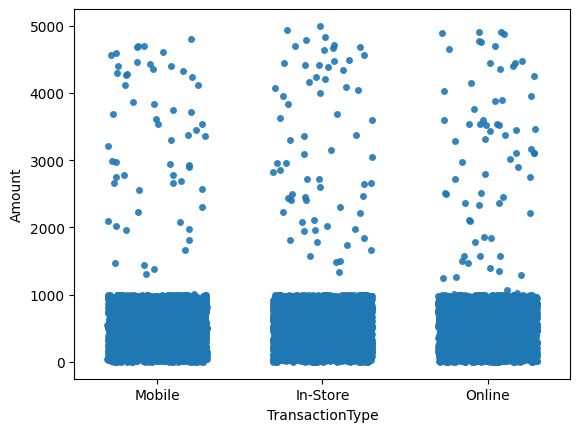

In [485]:
# strip plot
sns.stripplot(
    x="TransactionType",
    y="Amount",
    data=data,
    jitter=0.3,
    alpha=0.9
    )

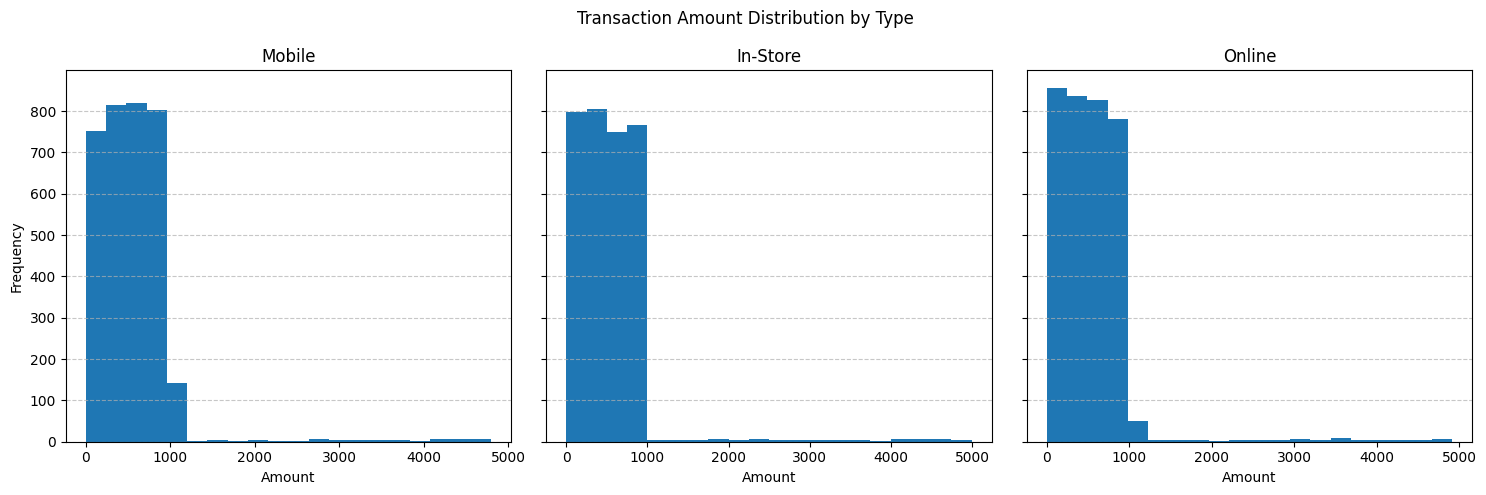

In [486]:
# histogram: transaction amount distribution by type
fig, ax = plt.subplots(1, len(data["TransactionType"].unique()), figsize=(15,5), sharey=True)
tx_types = data["TransactionType"].unique()
for i, tx_type in enumerate(tx_types):
    subset = data[data["TransactionType"] == tx_type]
    ax[i].hist(subset["Amount"], bins=20)
    ax[i].set_title(tx_type)
    ax[i].set_xlabel("Amount")
    ax[i].grid(axis="y", linestyle="--", alpha=0.7)

ax[0].set_ylabel("Frequency")
plt.suptitle("Transaction Amount Distribution by Type")
plt.tight_layout()
plt.show()

# Transaction Amounts per Transaction Class and Type

Fraudulent transactions are more concentrated in lower-to-mid ranges (roughly \$100–\$1,000), while normal transactions are more widely dispersed, including a larger number of high-value observations. Visualizations further suggest that fraud is less frequent in In-Store transactions and more prevalent in Mobile and Online channels. Overall, transaction amount alone is not a strong discriminator of fraud, but it becomes more informative when considered jointly with transaction type and distributional patterns.

In [487]:
# fraudulent transaction amounts per transaction type
data.pivot_table(
    index=["Class","TransactionType"],
    values="Amount",
    aggfunc=["count","mean","median","min","max"]
)

count        mean median    min    max
                           Amount      Amount Amount Amount Amount
Class      TransactionType                                        
Fraudulent Mobile             110  543.790909  436.5     10   4703
           Online             123  547.487805  435.0      2   4903
Normal     In-Store          3189  553.194732  496.0      1   4995
           Mobile            3283  554.687176  519.0      1   4801
           Online            3295  543.242489  497.0      1   4912

<Axes: xlabel='TransactionType', ylabel='Amount'>

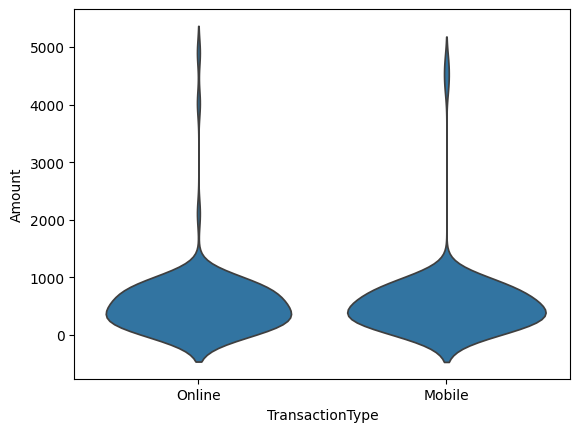

In [488]:
# violin plot: fraudulent transaction aounts by type
sns.violinplot(
    data=data[data["Class"] == "Fraudulent"],
    x="TransactionType",
    y="Amount",
    inner=None
)

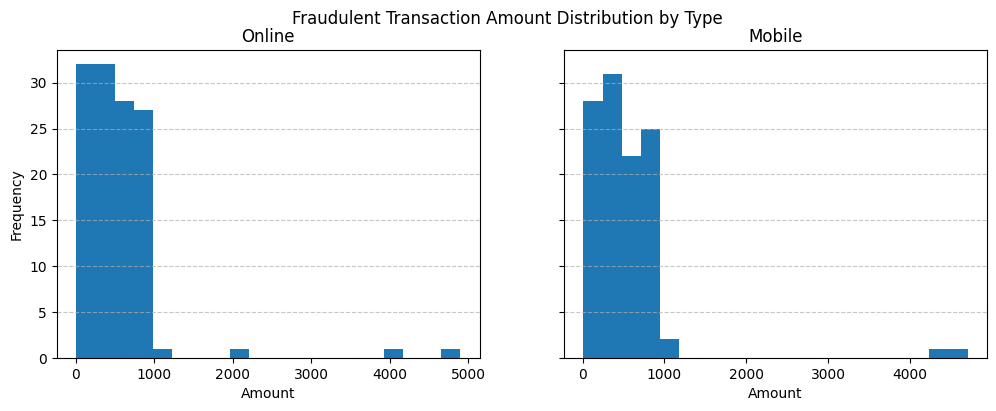

In [497]:
# histograms: fraudulent transaction amounts by type
fig, ax = plt.subplots(1, 2, figsize=(12,4), sharey=True)
tx_types = ["Online","Mobile"]
for i, tx_type in enumerate(tx_types):
    fraud_subset = data[data["Class"] == "Fraudulent"]
    subset = fraud_subset[fraud_subset["TransactionType"] == tx_type]
    ax[i].hist(subset["Amount"], bins=20)
    ax[i].set_title(tx_type)
    ax[i].set_xlabel("Amount")
    ax[i].grid(axis="y", linestyle="--", alpha=0.7)
ax[0].set_ylabel("Frequency")
plt.suptitle("Fraudulent Transaction Amount Distribution by Type")
plt.show()

<Axes: xlabel='TransactionType', ylabel='Amount'>

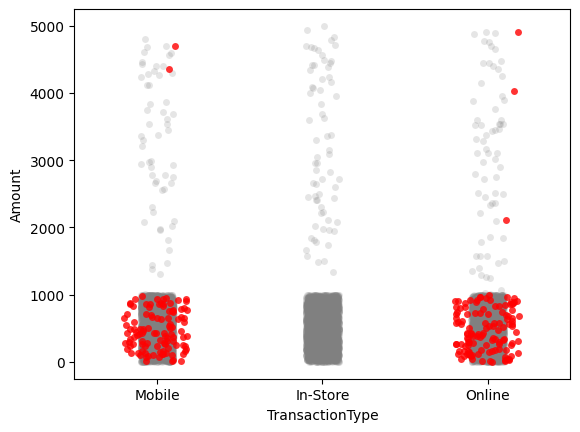

In [490]:
# strip plot #1

# normal
sns.stripplot(
    x="TransactionType",
    y="Amount",
    data=data[data["Class"] == "Normal"],
    color="gray",
    alpha=0.2
)

# fraud
sns.stripplot(
    x="TransactionType",
    y="Amount",
    data=data[data["Class"] == "Fraudulent"],
    color="red",
    jitter=0.2,
    alpha=0.8
)

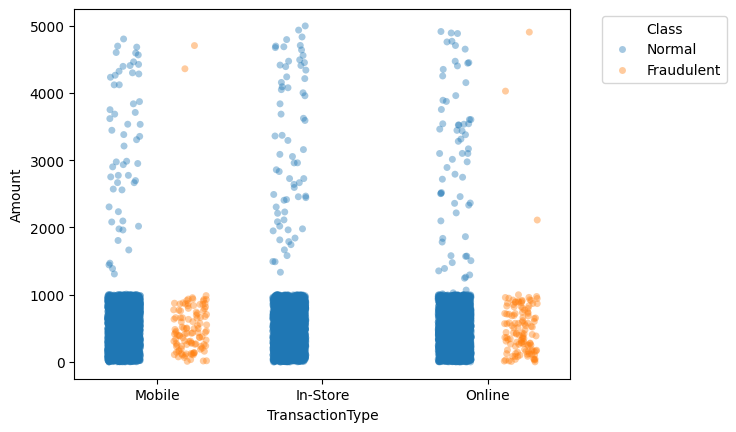

In [491]:
# strip plot #2

sns.stripplot(
    x="TransactionType",
    y="Amount",
    data=data,
    hue="Class",
    jitter=0.2,
    alpha=0.4,
    dodge=True   # separate by class
)

plt.legend(
    title="Class",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()